# Option Pricing: Black-Scholes, Heston, and Merton
This notebook aims to replicate the three models to learn more about them and how they are used to price options. Its mainly an exercise in implementation of existing models and trying to see how they work.



<div style="border-left: 4px solid #2196F3; padding-left: 15px;">
    
**1. Black-Scholes: The benchmark model assuming constant volatility.**  
_Provides a great baseline and is computationally efficient, but assumes constant $\sigma$ which is unrealistic for modern markets._
</div>

<span style="color:gray; opacity: 0.5;">**2. Heston:** Adds stochastic volatility (volatility clustering and mean reversion).</span>  
    <span style="color:gray; opacity: 0.5;">_Captures the "Smirk" or "Skew" via stochastic vol—essential for pricing OTM puts accurately._</span>
    
<span style="color:gray; opacity: 0.5;">**3. Merton Jump:** Adds "jumps" to the asset price to model market shocks.</span>  
    <span style="color:gray; opacity: 0.5;">_Captures "Fat Tails" and sudden crashes via Poisson jumps._</span>

## 1. Black-Scholes Model

The Black-Scholes model assumes the stock price $S_t$ follows a Geometric Brownian Motion (GBM):$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

We can deconstruct this engine into two distinct components:
* **The Deterministic Drift ($\mu S_t dt$):** This represents the expected, constant growth rate of the asset. If market volatility were zero, the stock would simply grow smoothly at rate $\mu$, compounding like money in a standard savings account.
  
* **The Stochastic Diffusion ($\sigma S_t dW_t$):** This injects the randomness. $dW_t$ is a Wiener process (Standard Brownian Motion) representing unpredictable market shocks. By scaling this randomness by the current stock price ($S_t$), the model ensures that the asset price can never drop below zero, perfectly reflecting the reality of limited liability in equities.
Where:   
- $\mu$ is the drift.  
- $\sigma$ is the constant volatility.  
- $dW_t$ is a Wiener process (Brownian motion). 
<br>

From this base of the stock price movement, given that there is a stochastic weiner process involved, we use ito's lemma, which allows for finding the differential of a stochastic process to get the BS PDE which gives the chnage in the option price for a chnage in the underlying stock price. 

From the BS PDE, we use no-arbitrage theory to get the BS formula for the price of an European Call option, as shown below.

**Call Option Formula**  
The price of a European Call option $C(S, t)$ is given by:  
$$C(S, t) = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
<br>
Where $N(\cdot)$ is the cumulative distribution function of the standard normal distribution, and:  
$$d_1 = \frac{\ln(S_0/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$$$$d_2 = d_1 - \sigma\sqrt{T}$$  

###
**Volatility Drag (The Asymmetry of Returns):**  
Because asset returns compound geometrically, downward price movements penalize the overall value more severely than upward movements of the exact same percentage. A 50% drop requires a 100% gain just to recover the initial capital. 

Mathematically, this "volatility drag" manifests when we apply Ito's Lemma to the log-return process, introducing a $-\frac{1}{2}\sigma^2$ variance penalty term. The higher the volatility, the stronger this downward drag on the expected geometric return.

## Imports and Setup

### Getting the .env file

In [2]:
# Magic commands for instant reloading of src code
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path
from dotenv import load_dotenv

# 1. Dynamically find the root folder ('options-projects-suite')
# Path.cwd() is the 'projects/subfolder', so we go up two levels.
root_dir = Path.cwd().parent.parent

# 2. Add root to system path so Python can find the 'src' package
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

# 3. Load the .env file explicitly from the root directory
load_dotenv(root_dir / ".env")

print(f"System path linked to: {root_dir}")

System path linked to: C:\Github Code\options-projects-suite


### Imports required for this project

In [57]:
# Numerical and Data Analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.colors as pcolors # Import Plotly's color module
from mpl_toolkits.mplot3d import Axes3D

# Statistics and Integration
import scipy.stats as si
from scipy.integrate import quad

# Interactive Widgets and Notebook Display
import ipywidgets as widgets
from IPython.display import display, clear_output
from IPython.display import HTML

import warnings

# Import your newly structured packages
from src.data.option_data_loader import MarketDataLoader
from src.models.option_pricing_math_engine import bs_call_price, implied_volatility

### Importing data from the WRDS option directory specified in the .env file

In [4]:
# Fetch the WRDS directory from your .env
env_path = os.environ.get("DATA_DIR")
if not env_path:
    raise ValueError("DATA_DIR not found. Check your .env file!")

# Build the exact path to the options data
options_dir = Path(env_path) / "WRDS Data" / "Options Data"

# Initialize the loader (this will trigger your print statements and load the df)
loader = MarketDataLoader(options_dir)

Loading Options, Spot, Yield, and Dividend Data into memory...
✅ Data Loaded Successfully.


### Parameters and extracting the strikes required

In [25]:
# Set plotting style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Parameters for simulation
S0_sim = 100      # Initial stock price
mu_sim = 0.08     # Expected return (drift)
sigma_sim = 0.20  # Volatility
T_sim = 1.0       # Time horizon (1 year)
dt_sim = 1/252    # Daily steps
num_paths = 15    # Number of simulated paths to plot

# 1. Explicitly define your scenario variables so the plotter can see them later
TARGET_DATE = '2024-01-10'
TARGET_EXDATE = '2024-02-16'

# 2. Feed them to the loader to get the exact state
state = loader.get_market_state(TARGET_DATE, TARGET_EXDATE, strike_bound_pct=0.10)

# 3. Extract the variables for the optimizer
S0, T, r, q = state['S0'], state['T'], state['r'], state['q']
market_strikes, market_prices = state['strikes'], state['prices']

print(f"✅ Loaded {len(market_strikes)} strikes. S0: {S0}, r: {r*100:.2f}%")

✅ Loaded 352 strikes. S0: 4783.45, r: 5.37%


### Monte Carlo Simulation of stock prices using a log-normal random walk with constant drift and volatility


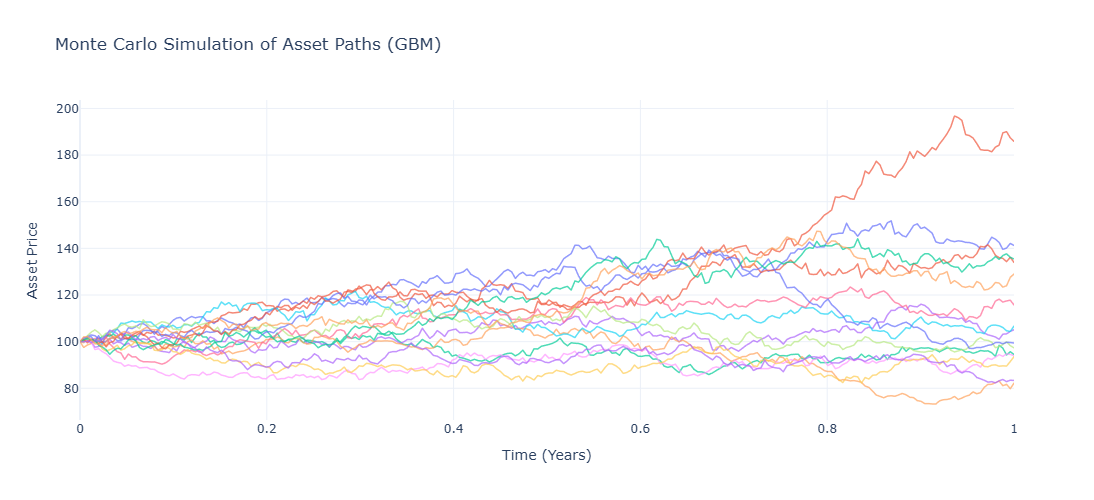

In [28]:
from src.models.option_pricing_math_engine import simulate_gbmm

# 1. Run the corrected simulation
t_steps, paths = simulate_gbm(S0_sim, mu_sim, sigma_sim, T_sim, dt_sim, num_paths)

# 2. Build the figure
fig = go.Figure()
x_flat = np.array(t_steps).flatten()

for i in range(num_paths):
    # Change Scattergl to Scatter if the red box persists in your environment
    fig.add_trace(go.Scattergl(  
        x=x_flat, 
        y=np.array(paths[i, :]).flatten(),
        mode='lines',
        line=dict(width=1.5),
        opacity=0.7,
        name=f'Path {i+1}',
        showlegend=False
    ))

fig.update_layout(
    title='Monte Carlo Simulation of Asset Paths (GBM)',
    xaxis_title='Time (Years)',
    yaxis_title='Asset Price',
    template='plotly_white',
    hovermode='closest', 
    width=900,
    height=500
)

fig.show()

### Black-Scholes Call Pricing & The Greeks

We use the Black-Scholes closed-form solution for european options to visualise how the "Big Five" Greeks ($\Delta$, $\Gamma$, $\Theta$, $\nu$, $\rho$) change against the underlying 

By visualizing these simultaneously, we can analyze the multi-dimensional risk exposure of an option contract as the underlying spot price moves across different moneyness levels.

In [29]:
from src.models.option_pricing_math_engine import bs_call_delta, bs_gamma, bs_call_theta, bs_vega, bs_call_rho
from plotly.subplots import make_subplots

# 1. Define UI Widgets for all BS parameters [cite: 17-19, 166]
vol_slider = widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.05, description='Sigma (σ)')
time_slider = widgets.FloatSlider(value=1.0, min=0.01, max=2.0, step=0.1, description='Time (T)')
strike_slider = widgets.FloatSlider(value=100, min=50, max=150, step=1, description='Strike (K)')
rate_slider = widgets.FloatSlider(value=0.05, min=0.0, max=0.2, step=0.01, description='Rate (r)')
div_slider = widgets.FloatSlider(value=0.0, min=0.0, max=0.1, step=0.01, description='Div (q)')

def update_greeks_full(vol, T_val, K_val, r_val, q_val):
    S_range = np.linspace(50, 150, 100)
    
    # Calculate fresh data using your math engine [cite: 161, 168-171]
    d = [bs_call_delta(S, K_val, T_val, r_val, q_val, vol) for S in S_range]
    g = [bs_gamma(S, K_val, T_val, r_val, q_val, vol) for S in S_range]
    t = [bs_call_theta(S, K_val, T_val, r_val, q_val, vol) for S in S_range]
    v = [bs_vega(S, K_val, T_val, r_val, q_val, vol) for S in S_range]
    p = [bs_call_rho(S, K_val, T_val, r_val, q_val, vol) for S in S_range]
    
    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=('Delta (Δ)', 'Gamma (Γ)', 'Theta (Θ)', 'Vega (ν)', 'Rho (ρ)'),
        horizontal_spacing=0.1, vertical_spacing=0.15
    )
    
    # Map data with original color scheme 
    plots = [(d, 'purple', 1, 1), (g, 'blue', 1, 2), (t, 'red', 1, 3), (v, 'green', 2, 1), (p, 'orange', 2, 2)]
    
    for data, color, row, col in plots:
        fig.add_trace(go.Scatter(x=S_range, y=data, line=dict(color=color, width=2), showlegend=False), row=row, col=col)
        fig.add_vline(x=K_val, line_dash="dash", line_color="black", row=row, col=col)

    fig.update_layout(height=700, width=1000, template='plotly_white', title_text="Dynamic Black-Scholes Greeks")
    fig.show()

# 2. Link all 5 sliders to the output 
ui = widgets.VBox([
    widgets.HBox([vol_slider, time_slider, strike_slider]),
    widgets.HBox([rate_slider, div_slider])
])

out = widgets.interactive_output(update_greeks_full, {
    'vol': vol_slider, 'T_val': time_slider, 'K_val': strike_slider, 
    'r_val': rate_slider, 'q_val': div_slider
})

display(ui, out)

Output()

### European Put option pricing

We add European Put options, running a computational check to validate our formulas against the Put-Call Parity theorem ($C - P = S_0 e^{-qT} - K e^{-rT}$), ensuring our engine respects fundamental no-arbitrage constraints.

In [30]:
from src.models.option_pricing_math_engine import bs_put_price

K_fixed, T_fixed, r_fixed, q_fixed, sigma_fixed = 100, 1.0, 0.05, 0.0, 0.2

# --- Put-Call Parity Validation ---
C = bs_call_price(S0_sim, K_fixed, T_fixed, r_fixed, q_fixed, sigma_fixed)
P = bs_put_price(S0_sim, K_fixed, T_fixed, r_fixed, q_fixed, sigma_fixed)

lhs = C - P
rhs = S0_sim * np.exp(-q_fixed * T_fixed) - K_fixed * np.exp(-r_fixed * T_fixed)

print(f"Put-Call Parity Check:")
print(f"LHS (Call - Put): {lhs:.4f}")
print(f"RHS (Discounted S - Discounted K): {rhs:.4f}")
print(f"Difference: {abs(lhs - rhs):.1e} (Effectively Zero)")

Put-Call Parity Check:
LHS (Call - Put): 4.8771
RHS (Discounted S - Discounted K): 4.8771
Difference: 0.0e+00 (Effectively Zero)


### The Options Pricing Surface

Options pricing is inherently multi-dimensional. The price is not just a function of the underlying asset's price, but also its strike price and the time remaining until expiration. 

By calculating the Black-Scholes price across a grid of different strikes and maturities, we can generate a 3D pricing surface. This visualizes how Out-Of-The-Money (OTM) options lose value rapidly as expiration approaches, while In-The-Money (ITM) options converge exactly to their intrinsic payoff.

In [41]:
from src.models.option_pricing_math_engine import bs_call_price

# 1. Define the 1D ranges
K_list = np.linspace(80, 120, 50)  # Strikes 
T_list = np.linspace(0.1, 2.0, 50) # Time to Maturity (e.g., 0.1 to 2 years)

# 2. Create the 2D meshgrid required for 3D surfaces
K_mesh, T_mesh = np.meshgrid(K_list, T_list)

# 3. Define fixed parameters used in your redraw_plot function
S_fixed = 100.0   # Spot price 
q_fixed = 0.0     # Dividend yield

# --- 1. Use standard Figure (not FigureWidget) for this method ---
fig = go.Figure(data=[
    go.Surface(
        x=K_mesh, 
        y=T_mesh, 
        z=np.zeros_like(T_mesh), 
        colorscale='viridis',
        contours={"z": {"show": True, "usecolormap": True, "project_z": True}}
    )
])

fig.update_layout(
    title='Interactive Options Surface',
    scene=dict(xaxis_title='Strike (K)', yaxis_title='Time (T)', zaxis_title='Value'),
    width=800, height=600,
    margin=dict(l=0, r=0, b=0, t=50)
)

# Create a container to hold the plot and errors
plot_output = widgets.Output()

# --- 2. Define the Update Logic ---
def redraw_plot(vol, rate, metric):
    with plot_output:
        clear_output(wait=True) # Prevent flickering
        
        # Calculate new Z data
        if metric == 'Call Price':
            Z_new = bs_call_price(S_fixed, K_mesh, T_mesh, rate, q_fixed, vol)
        elif metric == 'Call Delta': 
            Z_new = bs_call_delta(S_fixed, K_mesh, T_mesh, rate, q_fixed, vol)
        else:
            Z_new = bs_gamma(S_fixed, K_mesh, T_mesh, rate, q_fixed, vol)
        
        # Update the figure data
        fig.data[0].z = Z_new
        fig.show()


# 1. Define the Volatility Slider (sigma)
vol_slider = widgets.FloatSlider(
    value=0.20, 
    min=0.05, 
    max=1.0, 
    step=0.05, 
    description='Volatility:',
    continuous_update=False # Improves performance for 3D surfaces
)

# 2. Define the Risk-Free Rate Slider (r)
rate_slider = widgets.FloatSlider(
    value=0.05, 
    min=0.0, 
    max=0.2, 
    step=0.01, 
    description='rf Rate:',
    continuous_update=False
)

# 3. Define the Metric Dropdown
metric_dropdown = widgets.Dropdown(
    options=['Call Price', 'Call Delta', 'Call Gamma'],
    value='Call Price',
    description='Metric:'
)

# --- 3. Link UI Controls ---
# We use interactive_output to link the function to the sliders
ui = widgets.HBox([vol_slider, rate_slider, metric_dropdown])

out = widgets.interactive_output(redraw_plot, {
    'vol': vol_slider, 
    'rate': rate_slider, 
    'metric': metric_dropdown
})

# --- 4. Display Everything ---
display(ui, plot_output)

Output()

We use a Brent root-finding algorithm to back-calculate the market's implied volatility from our observed option prices. The resulting plot proves that the Black-Scholes assumption of constant volatility is empirically false—setting up the necessity for the advanced, volatility-skew-aware models in the subsequent notebooks.

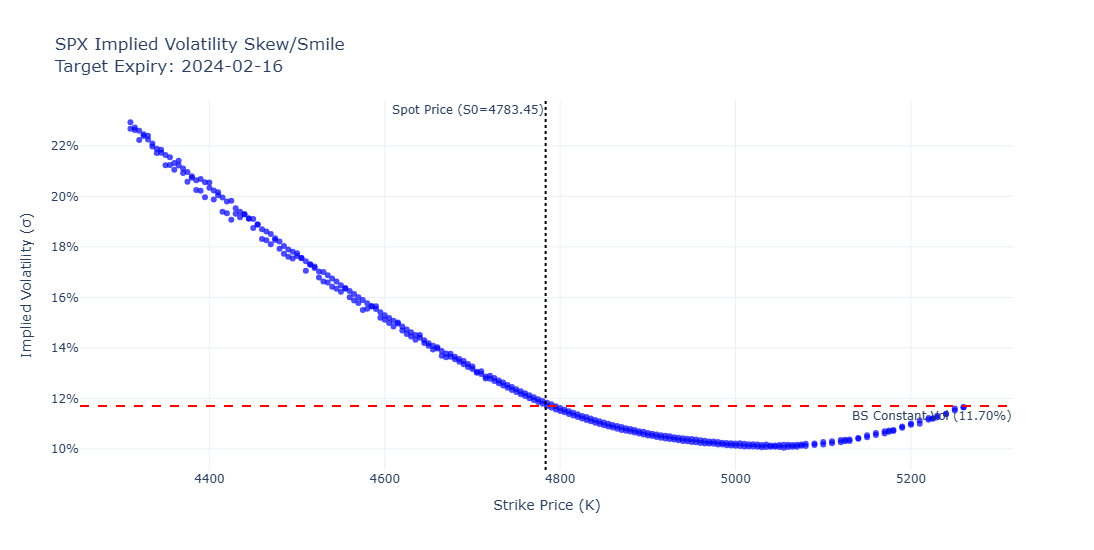

In [48]:
from src.models.option_pricing_math_engine import implied_volatility

# 1. Back-calculate Market IV with a safety filter
valid_strikes = []
valid_ivs = []

for K, price in zip(market_strikes, market_prices):
    try:
        iv = implied_volatility(price, S0, K, T, r, q) 
        
        # Filter out NaNs and absurdly high IVs (> 200%) from stale penny quotes
        if iv is not None and not np.isnan(iv) and iv > 0 and iv < 2.0: 
            valid_strikes.append(K)
            valid_ivs.append(iv)
    except Exception:
        # Ignore strikes that cause the math engine to crash
        continue

# Convert to clean arrays
clean_strikes = np.array(valid_strikes)
clean_ivs = np.array(valid_ivs)

# 2. Calculate the ATM Volatility safely from the CLEAN data
if len(clean_strikes) > 0:
    idx_atm = np.abs(clean_strikes - S0).argmin()
    atm_vol = clean_ivs[idx_atm]
else:
    atm_vol = 0.15 # Fallback if everything fails

# Initialize Figure
fig = go.Figure()

# 1. Add the Market Implied Volatility points using clean data
fig.add_trace(go.Scatter(
    x=clean_strikes,
    y=clean_ivs,
    mode='markers',
    name='Market Implied Volatility',
    marker=dict(color='blue', size=6, opacity=0.7),
    hovertemplate='Strike: %{x}<br>IV: %{y:.2%}<extra></extra>'
))

# 2. Add the Constant BS Assumption (ATM Vol) line 
fig.add_hline(
    y=atm_vol, 
    line_dash="dash", 
    line_color="red",
    annotation_text=f"BS Constant Vol ({atm_vol:.2%})", 
    annotation_position="bottom right"
)

# 3. Add the Spot Price (S0) vertical line 
fig.add_vline(
    x=S0, 
    line_dash="dot", 
    line_color="black",
    annotation_text=f"Spot Price (S0={S0:.2f})", 
    annotation_position="top left"
)

# 4. Final Layout Styling 
fig.update_layout(
    title=f'SPX Implied Volatility Skew/Smile<br>Target Expiry: {TARGET_EXDATE}',
    xaxis_title='Strike Price (K)',
    yaxis_title='Implied Volatility (σ)',
    yaxis=dict(tickformat='.0%'),
    template='plotly_white',
    hovermode='x unified',
    width=900,
    height=550,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

# Option Pricing: Black-Scholes, Heston, and Merton
## Overall Objective: Understand and compare three fundamental option pricing models.

<span style="color:gray; opacity: 0.5;">**1. Black-Scholes:** The benchmark model assuming constant volatility.</span>  
    <span style="color:gray; opacity: 0.5;">_Provides a great baseline and is computationally efficient, but assumes constant $\sigma$ which is unrealistic for modern markets._</span>

<div style="border-left: 4px solid #2196F3; padding-left: 15px;">

**2. Heston: Adds stochastic volatility (volatility clustering and mean reversion).**   
_Captures the "Smirk" or "Skew" via stochastic vol—essential for pricing OTM puts accurately._
</div>

<span style="color:gray; opacity: 0.5;">**3. Merton Jump:** Adds "jumps" to the asset price to model market shocks.</span>  
    <span style="color:gray; opacity: 0.5;">_Captures "Fat Tails" and sudden crashes via Poisson jumps._</span>


# Model 2: The Heston Stochastic Volatility Model
## Objective: Capturing the "Leverage Effect" and Volatility Clustering

The Black-Scholes model assumes volatility is a constant number. However, looking at the VIX, we know that volatility is highly dynamic. It clusters (high vol periods follow high vol periods) and it mean-reverts (eventually calms down).

Steven Heston (1993) solved this by modeling the asset price and its variance as two correlated, random processes:

### The Mathematical Intuition
The Heston model is governed by two Stochastic Differential Equations (SDEs):

1. **The Asset Price Process:** $$\frac{dS_t}{S_t} = \mu dt + \sqrt{v_t} dW_t^S$$
2. **The Variance Process (CIR Process):** $$dv_t = \kappa(\theta - v_t)dt + \xi \sqrt{v_t} dW_t^v$$

**The Parameters:**
* $v_0$: Initial Variance.
* $\theta$ (Theta): Long-term average variance.
* $\kappa$ (Kappa): The rate of mean reversion (how fast vol returns to $\theta$).
* $\xi$ (Xi): Volatility of Volatility (determines the convexity of the smile).
* $\rho$ (Rho): The Correlation between the two Brownian motions ($dW_t^S$ and $dW_t^v$). 

**Asset Price Process:** Compared to the BS model where the $\sigma$ term is a fixed number, we model the variance with its own separate random process that chnages over time.

**The Magic of $\rho$:** The two Brownian motions ($dW_t^S$ for price and $dW_t^v$ for variance) are typically correlated by a factor $\rho$. In equity markets like the S&P 500, $\rho$ is heavily negative (around -0.7). This is what allows Heston to model the leverage effect, when the market crashes, volatility explodes. This negative correlation is what mathematically drags the left side of the volatility smile upward, creating the "Skew."

### Pricing via Characteristic Functions

Since there is no simple closed-form solution like Black-Scholes, we use the Fourier Transform method. The price is an integral of the Characteristic Function $\phi$.

**Important Note on Stability (Albrecher et al.):**

Standard implementations of the Heston characteristic function often suffer from "branch cut" discontinuities, leading to numerical explosions (sawtooth graphs). We use the "Albrecher" representation to ensure the characteristic function remains continuous and stable.

## Imports and Setup

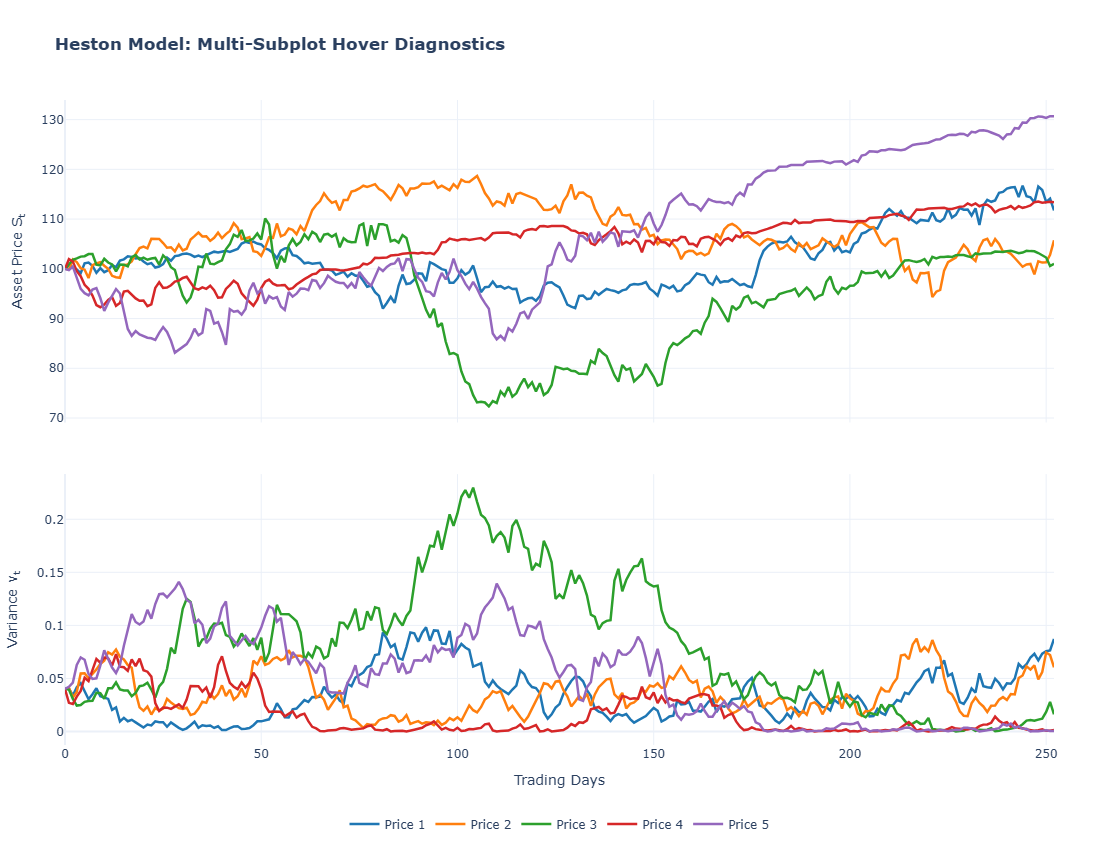

In [105]:
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pcolors

# --- 1. Simulation Parameters [cite: 1, 422-428] ---
S0, v0 = 100.0, 0.04
kappa, theta, xi = 3.0, 0.04, 0.6
rho, r, T = -0.7, 0.05, 1.0
steps = 252
dt = T / steps
n_paths = 5
np.random.seed(42)

# --- 2. Generate Paths [cite: 1, 477-486] ---
Z1 = np.random.standard_normal((steps, n_paths))
Z2 = np.random.standard_normal((steps, n_paths))
Z_S, Z_v = Z1, rho * Z1 + np.sqrt(1 - rho**2) * Z2

S, v = np.zeros((steps + 1, n_paths)), np.zeros((steps + 1, n_paths))
S[0], v[0] = S0, v0

for t in range(1, steps + 1):
    v_prev = np.maximum(v[t-1], 0)
    dv = kappa * (theta - v_prev) * dt + xi * np.sqrt(v_prev) * np.sqrt(dt) * Z_v[t-1]
    v[t] = np.maximum(v_prev + dv, 0)
    dS = r * S[t-1] * dt + np.sqrt(v_prev) * S[t-1] * np.sqrt(dt) * Z_S[t-1]
    S[t] = S[t-1] + dS

# --- 3. Build Figure using Stacked Grid Logic  ---
fig = go.Figure()
x_steps = np.arange(steps + 1)
palette = pcolors.DEFAULT_PLOTLY_COLORS

for i in range(n_paths):
    color = palette[i % len(palette)]
    label = f"Path {i+1}"
    
    # --- 1. Background Layer (Grey Lines) ---
    # We set hoverinfo to 'skip' so these don't interfere with the labels
    fig.add_trace(go.Scatter(
        x=x_steps, y=S[:, i], xaxis="x", yaxis="y",
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=x_steps, y=v[:, i], xaxis="x", yaxis="y2",
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ))

    # --- 2. Foreground Layer (Colored Interactive Lines) ---
    fig.add_trace(go.Scatter(
        x=x_steps, y=S[:, i], xaxis="x", yaxis="y",
        name=f"Price {i+1}", legendgroup=label,
        line=dict(color=color, width=2.5),
        hovertemplate='Price: %{y:.2f}<extra></extra>'
    ))
    fig.add_trace(go.Scatter(
        x=x_steps, y=v[:, i], xaxis="x", yaxis="y2",
        name=f"Var {i+1}", legendgroup=label,
        line=dict(color=color, width=2.5),
        showlegend=False,
        hovertemplate='Var: %{y:.4f}<extra></extra>'
    ))

# --- 4. Consolidated Layout Control ---
fig.update_layout(
    title="<b>Heston Model: Multi-Subplot Hover Diagnostics</b>",
    
    # SPLIT HOVER: Separate pop-ups in each graph 
    hovermode="x", 
    hoversubplots="axis",
    
    # GRID & SPACING: Manual domain settings create the vertical gap
    grid=dict(rows=2, columns=1, roworder='top to bottom'),
    yaxis=dict(title="Asset Price S<sub>t</sub>", domain=[0.50, 1.0]), 
    yaxis2=dict(title="Variance v<sub>t</sub>", domain=[0.0, 0.42]),
    
    # X-AXIS SPIKES: The vertical dashed line tracking the mouse
    xaxis=dict(
        title="Trading Days",
        showspikes=True,
        spikemode="across",
        spikesnap="cursor",
        spikecolor="black",
        spikethickness=1,
        spikedash="dash"
    ),
    
    # LEGEND: Bottom center with Isolation behavior
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.1, 
        xanchor="center",
        x=0.5,
        itemclick="toggleothers", # Clicking a path highlights only that one
        itemdoubleclick="toggle"
    ),
    
    template='plotly_white',
    height=850,
    width=1000,
    margin=dict(l=60, r=40, t=100, b=100)
)

fig.show(config={'displayModeBar': False})

Calculating Theoretical Smiles across different markets...


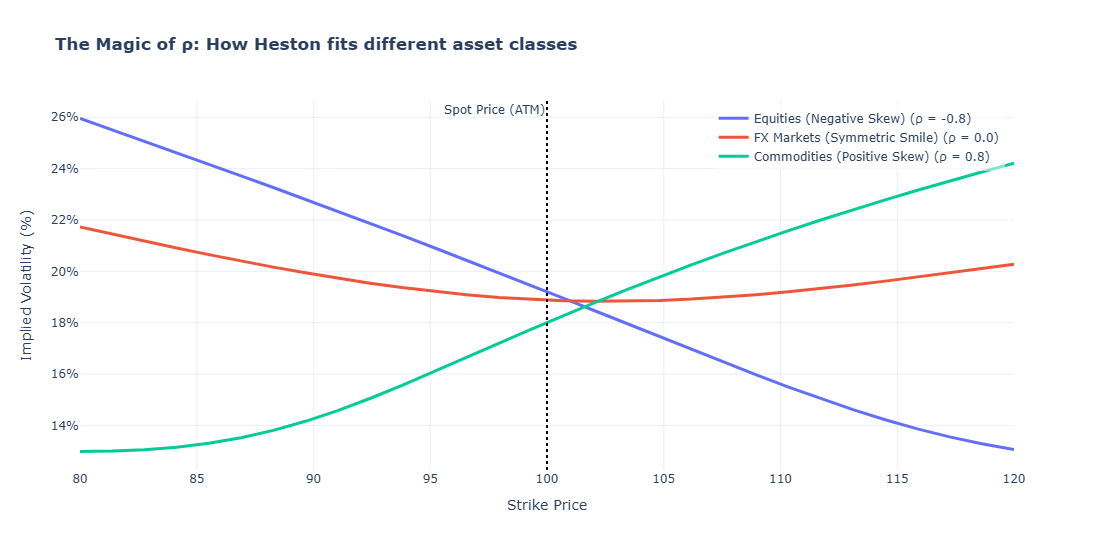

In [87]:
from src.models.option_pricing_math_engine import heston_call_price, implied_volatility

# --- 1. Define Model Parameters ---
S0_t = 100.0   # Spot Price 
T_t = 0.5      # Time to Expiration (6 months)
r_t = 0.05     # Risk-free rate
q_t = 0.0      # Dividend yield

# Heston-specific parameters 
v0_t = 0.04    # Initial Variance (20% Vol)
kappa_t = 2.0  # Speed of mean reversion
theta_t = 0.04 # Long-term variance
xi_t = 0.5     # Volatility of Volatility

# Define the strike range for the smile
strikes = np.linspace(80, 120, 30)

# Define the three correlation (rho) environments
correlations = {
    "Equities (Negative Skew)": -0.8,
    "FX Markets (Symmetric Smile)": 0.0,
    "Commodities (Positive Skew)": 0.8
}

# --- 2. Calculation and Plotting ---
fig = go.Figure()

print("Calculating Theoretical Smiles across different markets...")

for label, rho_test in correlations.items():
    ivs = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for K in strikes:
            # A. Get the Heston Price
            price = heston_call_price(S0_t, K, T_t, r_t, q_t, v0_t, kappa_t, theta_t, xi_t, rho_test)
            
            # B. Solve for Implied Volatility (IV)
            iv = implied_volatility(price, S0_t, K, T_t, r_t, q_t)
            ivs.append(iv * 100)
    
    # C. Add a trace for each correlation regime
    fig.add_trace(go.Scatter(
        x=strikes, 
        y=ivs,
        mode='lines',
        name=f"{label} (ρ = {rho_test})",
        line=dict(width=3),
        # Removes the redundant trace name box on the side
        hovertemplate='%{y:.2f}%<extra></extra>' 
    ))

# --- 3. Add Contextual Visual Markers ---
# Spot Price Vertical Line
fig.add_vline(
    x=S0_t, 
    line_dash="dot", 
    line_color="black",
    annotation_text="Spot Price (ATM)",
    annotation_position="top left"
)

# --- 4. Global Layout Control ---
fig.update_layout(
    title="<b>The Magic of ρ: How Heston fits different asset classes</b>",
    xaxis=dict(
        title="Strike Price",
        # Custom header for the unified hover box 
        unifiedhovertitle=dict(text="<b>Strike Price: %{x:.2f}</b>")
    ),
    yaxis=dict(
        title="Implied Volatility (%)",
        ticksuffix="%" # Displays as percentage on the axis
    ),
    template='plotly_white',
    hovermode='x unified', # Cross-compare all 3 lines at a single strike
    width=900,
    height=550,
    legend=dict(
        yanchor="top", y=0.99,
        xanchor="right", x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    )
)

fig.show(config={'displayModeBar': False})

# Option Pricing: Black-Scholes, Heston, and Merton
## Overall Objective: Understand and compare three fundamental option pricing models.

<span style="color:gray; opacity: 0.5;">**1. Black-Scholes:** The benchmark model assuming constant volatility.</span>  
    <span style="color:gray; opacity: 0.5;">_Provides a great baseline and is computationally efficient, but assumes constant $\sigma$ which is unrealistic for modern markets._</span>

<span style="color:gray; opacity: 0.5;">**2. Heston** : Adds stochastic volatility (volatility clustering and mean reversion).</span>  
    <span style="color:gray; opacity: 0.5;">_Captures "Fat Tails" and sudden crashes via Poisson jumps._</span>

    
<div style="border-left: 4px solid #2196F3; padding-left: 15px;">

**3. Merton Jump: Adds "jumps" to the asset price to model market shocks.**   
_Captures "Fat Tails" and sudden crashes via Poisson jumps._
</div>

# Model 3: The Merton Jump Diffusion Model (MJD)
## Objective: Capturing Market Shocks and "Fat Tails"

The Black-Scholes model assumes that stock prices follow a continuous, smooth path (Geometric Brownian Motion). However, in reality, markets experience sudden, discontinuous shocks—earnings surprises, macroeconomic news, or overnight crashes. 

Robert Merton (1976) extended the Black-Scholes model by adding a **Poisson Jump Process** to the continuous diffusion. 

### The Mathematical Intuition
The asset price dynamics under MJD are described by:
$$\frac{dS_t}{S_t} = (\mu - \lambda k) dt + \sigma dW_t + (J_t - 1) dN_t$$

Where:
1. **The Continuous Part ($\sigma dW_t$):** The standard Black-Scholes daily noise (Brownian motion).
2. **The Jump Counter ($dN_t$):** A Poisson process. Most days it is 0. Occasionally, it "fires" and equals 1. The frequency of jumps is governed by $\lambda$ (expected jumps per year).
3. **The Jump Size ($J_t$):** When a jump occurs, how big is it? Merton assumes the jump sizes are log-normally distributed, with a mean jump size ($\mu_j$) and a jump variance ($\delta^2$).

By adding these random jumps, the Merton model naturally creates the "Fat Tails" and "Left Skew" seen in real-world S&P 500 return distributions. Let's visualize this difference.

## Imports and Setup

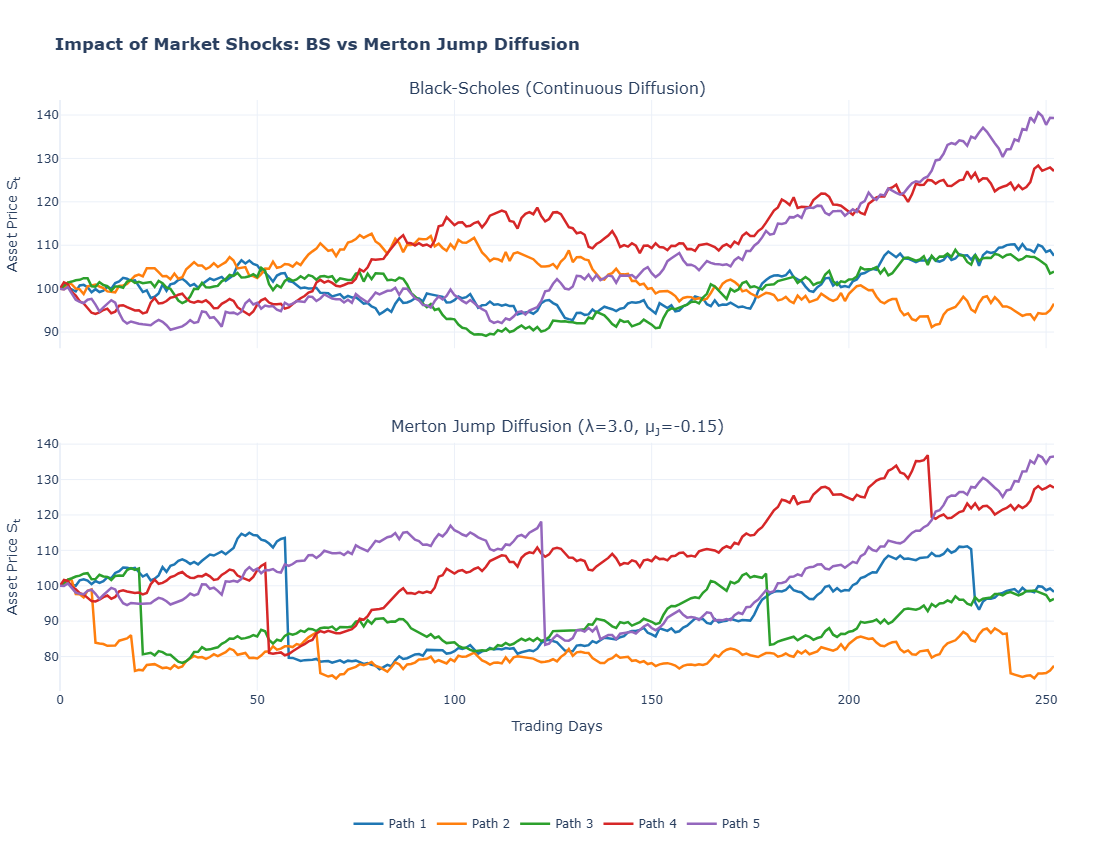

In [107]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pcolors

# --- 1. Simulation Parameters  ---
S0, T, r = 100, 1.0, 0.05
sigma, steps, n_paths = 0.15, 252, 5
dt = T / steps

# Merton Jump Parameters
lam = 3.0       # Expected jumps per year
mu_j = -0.15    # Mean jump size (15% drop)
delta = 0.10    # Jump volatility

# --- 2. Generate Paths  ---
np.random.seed(42)
Z = np.random.standard_normal((steps, n_paths)) # Continuous noise
N = np.random.poisson(lam * dt, (steps, n_paths)) # Jump counter
J = np.random.normal(mu_j, delta, (steps, n_paths)) # Jump sizes

# Black-Scholes Returns [cite: 598]
ret_bs = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Merton Returns with compensator 'k' 
k = np.exp(mu_j + 0.5 * delta**2) - 1
ret_merton = (r - lam * k - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z + N * J

S_bs = np.zeros((steps + 1, n_paths))
S_merton = np.zeros((steps + 1, n_paths))
S_bs[0], S_merton[0] = S0, S0

for t in range(1, steps + 1):
    S_bs[t] = S_bs[t-1] * np.exp(ret_bs[t-1])
    S_merton[t] = S_merton[t-1] * np.exp(ret_merton[t-1])

# --- 3. Initialize Vertical Subplots  ---
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.15, 
    subplot_titles=("Black-Scholes (Continuous Diffusion)", 
                    f"Merton Jump Diffusion (λ={lam}, μ<sub>J</sub>={mu_j})")
)

x_days = np.arange(steps + 1)
palette = pcolors.DEFAULT_PLOTLY_COLORS

# --- 4. Add Traces ---
for i in range(n_paths):
    color = palette[i % len(palette)]
    label = f"Path {i+1}"
    
    # Background Grey Layer (Non-interactive)
    fig.add_trace(go.Scatter(
        x=x_days, y=S_bs[:, i], mode='lines',
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=x_days, y=S_merton[:, i], mode='lines',
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ), row=2, col=1)

    # Foreground Colored Layer (Isolatable)
    # Left Subplot (BS)
    fig.add_trace(go.Scatter(
        x=x_days, y=S_bs[:, i], mode='lines',
        line=dict(color=color, width=2.5),
        name=label, legendgroup=label,
        hovertemplate='BS Price: %{y:.2f}<extra></extra>'
    ), row=1, col=1)
    
    # Right Subplot (Merton)
    fig.add_trace(go.Scatter(
        x=x_days, y=S_merton[:, i], mode='lines',
        line=dict(color=color, width=2.5),
        name=label, legendgroup=label,
        showlegend=False,
        hovertemplate='Merton Price: %{y:.2f}<extra></extra>'
    ), row=2, col=1)

# --- 5. Consolidated Layout Control ---
fig.update_layout(
    title="<b>Impact of Market Shocks: BS vs Merton Jump Diffusion</b>",
    
    # SPLIT HOVER: Independent boxes per graph
    hovermode="x", 
    hoversubplots="axis",
    
    # GRID & SPACING
    yaxis=dict(title="Asset Price S<sub>t</sub>", domain=[0.58, 1.0]), 
    yaxis2=dict(title="Asset Price S<sub>t</sub>", domain=[0.0, 0.42]),
    
    # X-AXIS SPIKES: Continuous vertical line tracking the cursor
    xaxis=dict(
        showspikes=True, spikemode="across", spikesnap="cursor",
        spikecolor="black", spikethickness=1, spikedash="dash"
    ),
    xaxis2=dict(
        title="Trading Days",
        showspikes=True, spikemode="across", spikesnap="cursor",
        unifiedhovertitle=dict(text="<b>Trading Day: %{x}</b>")
    ),
    
    # LEGEND: Bottom center with Isolation behavior
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2, 
        xanchor="center",
        x=0.5,
        itemclick="toggleothers", 
        itemdoubleclick="toggle"
    ),
    
    template='plotly_white',
    height=850,
    width=1000,
    margin=dict(l=60, r=40, t=100, b=100)
)

fig.show(config={'displayModeBar': False})

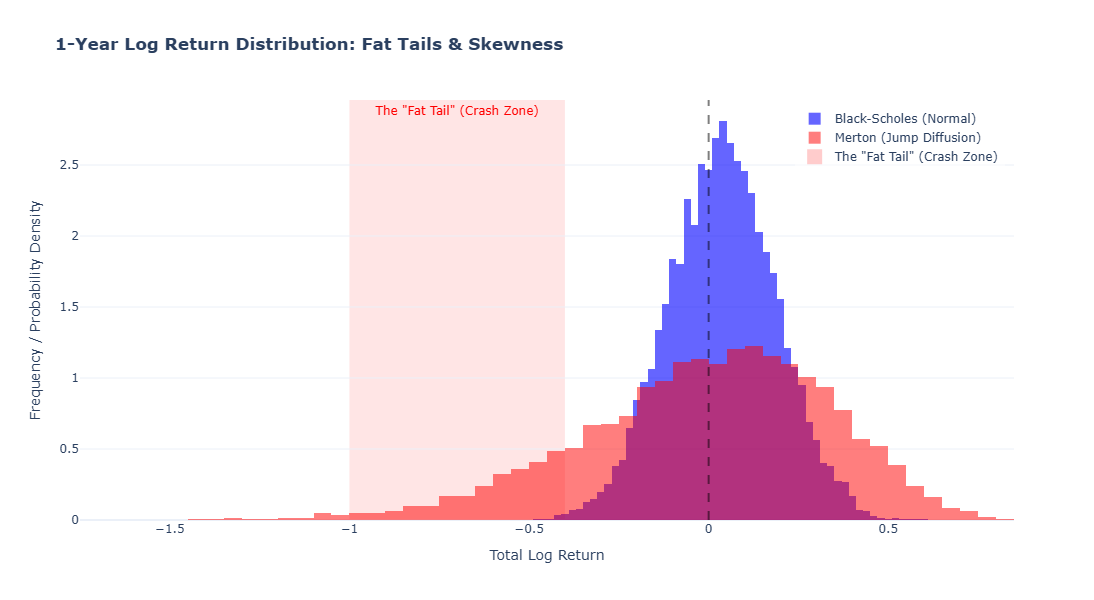

In [108]:
import numpy as np
import plotly.graph_objects as go

# --- 1. Simulation Parameters (Consistent with previous context)  ---
S0, T, r = 100, 1.0, 0.05
sigma, steps = 0.15, 252
n_sims = 10000 # High sample size for smooth distribution
dt = T / steps

# Merton Jump Parameters
lam = 3.0       # Expected jumps per year
mu_j = -0.15    # Mean jump size (15% drop)
delta = 0.10    # Jump volatility
k = np.exp(mu_j + 0.5 * delta**2) - 1 # Compensator [cite: 599]

# --- 2. Generate Random Variables & Distributions  ---
np.random.seed(42)
Z_dist = np.random.standard_normal((steps, n_sims))
N_dist = np.random.poisson(lam * dt, (steps, n_sims))
J_dist = np.random.normal(mu_j, delta, (steps, n_sims))

# Calculate Log Returns
ret_bs_dist = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_dist
ret_merton_dist = (r - lam * k - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_dist + N_dist * J_dist

# Total 1-Year Log Returns 
total_ret_bs = np.sum(ret_bs_dist, axis=0)
total_ret_merton = np.sum(ret_merton_dist, axis=0)

# --- 3. Initialize Plotly Figure ---
fig = go.Figure()

# Add Black-Scholes Histogram
fig.add_trace(go.Histogram(
    x=total_ret_bs,
    name='Black-Scholes (Normal)',
    nbinsx=100,
    histnorm='probability density',
    marker_color='blue',
    opacity=0.6,
    hovertemplate='BS Density: %{y:.4f}<extra></extra>'
))

# Add Merton Histogram [cite: 651]
fig.add_trace(go.Histogram(
    x=total_ret_merton,
    name='Merton (Jump Diffusion)',
    nbinsx=100,
    histnorm='probability density',
    marker_color='red',
    opacity=0.5,
    hovertemplate='Merton Density: %{y:.4f}<extra></extra>'
))

# --- 4. Add Visual Annotations ---
# Vertical line at Zero return
fig.add_vline(x=0, line_dash="dash", line_color="black", opacity=0.5)

# Highlight the "Crash" Zone (Fat Tail) [cite: 656]
fig.add_vrect(
    x0=-1.0, x1=-0.4, 
    fillcolor="red", opacity=0.1, 
    layer="below", line_width=0,
    label=dict(
        text='The "Fat Tail" (Crash Zone)', 
        textposition="top center",
        font=dict(size=12, color="red")
    )
)

# Dummy trace to add the Crash Zone to the Legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(color='rgba(255, 0, 0, 0.2)', symbol='square', size=15),
    name='The "Fat Tail" (Crash Zone)'
))

# --- 5. Consolidated Layout Control ---
fig.update_layout(
    title="<b>1-Year Log Return Distribution: Fat Tails & Skewness</b>",
    xaxis_title="Total Log Return",
    yaxis_title="Frequency / Probability Density",
    
    # Overlay histograms instead of stacking them
    barmode='overlay', 
    
    # Unified hover to compare densities at a specific return level
    hovermode='x unified',
    
    template='plotly_white',
    width=1000,
    height=600,
    
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    )
)

fig.show(config={'displayModeBar': False})

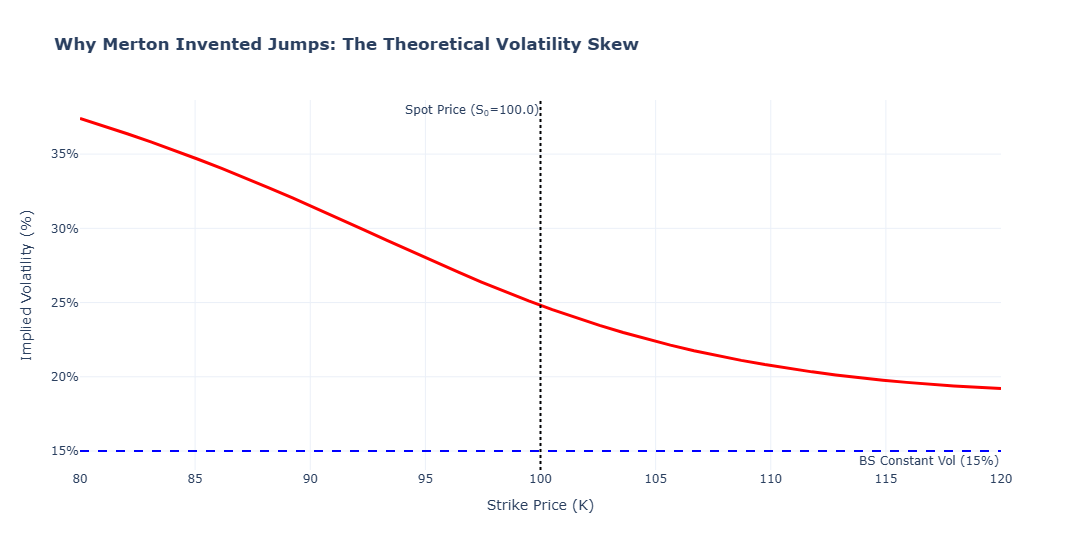

Calculated IVs: [37.39799323 36.89311423 36.3675406  35.81993105 35.2492413 ]
Number of NaNs: 0 out of 40


In [110]:
import numpy as np
import plotly.graph_objects as go
import warnings
from src.models.option_pricing_math_engine import merton_jump_call, implied_volatility

# --- 1. Define Theoretical Market Parameters  ---
S0 = 100.0
T = 0.25      # 3 months to expiration
r = 0.05
q = 0.0
theoretical_strikes = np.linspace(80, 120, 40)

# --- 2. Define Baseline vs Jump Parameters  ---
sigma_baseline = 0.15 
lam = 1.0     # 1 jump per year
mu_j = -0.20  # Average jump is a 20% market crash
delta = 0.15  # Volatility of the jump size

# --- 3. Calculate Prices and Convert to IV  ---
merton_ivs = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for K in theoretical_strikes:
        # Step A: Get the theoretical Merton Price
        m_price = merton_jump_call(S0, K, T, r, q, sigma_baseline, lam, mu_j, delta)
        
        # Step B: Back-calculate IV using Black-Scholes engine
        m_iv = implied_volatility(m_price, S0, K, T, r, q)
        merton_ivs.append(m_iv * 100) # Convert to percentage

merton_ivs = np.array(merton_ivs)

# --- 4. Initialize Plotly Figure ---
fig = go.Figure()

# Add the Merton Volatility Smile 
fig.add_trace(go.Scatter(
    x=theoretical_strikes, 
    y=merton_ivs,
    mode='lines',
    name='Merton Jump Diffusion',
    line=dict(color='red', width=3),
    hovertemplate='IV: %{y:.2f}%<extra></extra>'
))

# --- 5. Add Theoretical Annotations  ---
# Constant Black-Scholes Volatility Line
fig.add_hline(
    y=sigma_baseline * 100, 
    line_dash="dash", 
    line_color="blue",
    annotation_text=f"BS Constant Vol ({sigma_baseline*100:.0f}%)", 
    annotation_position="bottom right"
)

# Spot Price (ATM) Vertical Line
fig.add_vline(
    x=S0, 
    line_dash="dot", 
    line_color="black",
    annotation_text=f"Spot Price (S<sub>0</sub>={S0})", 
    annotation_position="top left"
)

# --- 6. Consolidated Layout Control ---
fig.update_layout(
    title="<b>Why Merton Invented Jumps: The Theoretical Volatility Skew</b>",
    xaxis=dict(
        title="Strike Price (K)",
        unifiedhovertitle=dict(text="<b>Strike Price: %{x:.2f}</b>")
    ),
    yaxis=dict(
        title="Implied Volatility (%)",
        ticksuffix="%"
    ),
    template='plotly_white',
    hovermode='x unified', # Perfectly compare the Skew vs. Baseline
    width=950,
    height=550,
    legend=dict(
        yanchor="top", y=0.99,
        xanchor="right", x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    )
)

fig.show(config={'displayModeBar': False})

# Debugging diagnostics 
print(f"Calculated IVs: {merton_ivs[:5]}") 
print(f"Number of NaNs: {np.isnan(merton_ivs).sum()} out of {len(merton_ivs)}")

# Model 4: The Bates Model (Stochastic Volatility with Jumps)
## Objective: The "Holy Grail" of Classical Option Pricing

We have seen that **Merton** perfectly captures the short-term skew (by adding sudden jumps/crashes), but struggles with long-term options. 
We have seen that **Heston** perfectly captures the long-term skew (using mean-reverting stochastic volatility), but struggles to bend the curve enough for short-term crashes without using absurd parameters.

David Bates (1996) combined them into the **SVJ Model** (Stochastic Volatility with Jumps). 

### The Mathematical Intuition
The Bates model simply takes the two Heston SDEs and adds the Merton Poisson jump counter directly to the asset price process:

1. **The Asset Price Process (Heston + Merton):** $$\frac{dS_t}{S_t} = (\mu - \lambda k) dt + \sqrt{v_t} dW_t^S + (J_t - 1) dN_t$$

2. **The Variance Process (Standard Heston):** $$dv_t = \kappa(\theta - v_t)dt + \xi \sqrt{v_t} dW_t^v$$

Because the Heston diffusion process and the Merton jump process are mathematically independent, Bates realized you could simply multiply their Characteristic Functions together. This created a single, unified model that can price the entire Volatility Surface (short-term and long-term) flawlessly.

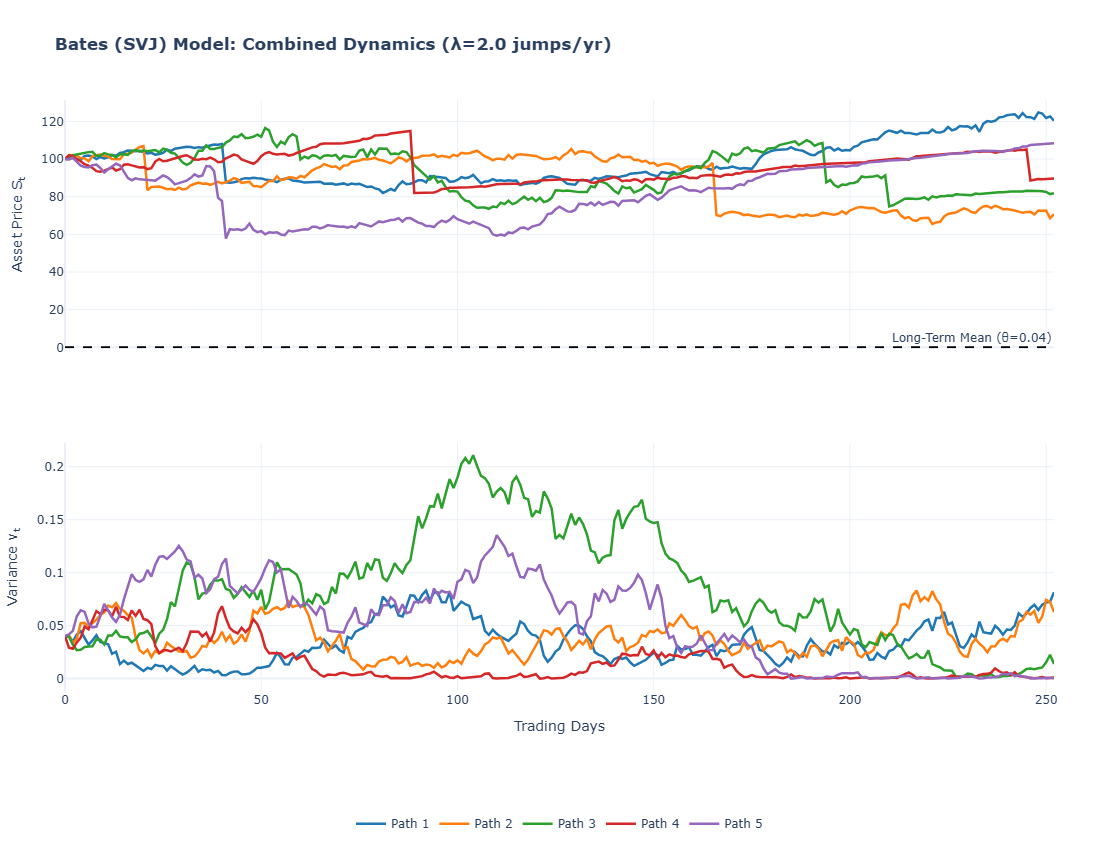

In [116]:
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pcolors

# --- 1. Bates Simulation Parameters  ---
S0, v0 = 100.0, 0.04
kappa, theta, xi = 2.0, 0.04, 0.5
rho, r, T = -0.7, 0.05, 1.0
steps = 252
dt = T / steps
n_paths = 5 # Increased for a better "ghosting" effect

# Jump Parameters (Merton)
lam, mu_j, delta = 2.0, -0.15, 0.10

# --- 2. Simulation Logic  ---
np.random.seed(42)
Z1 = np.random.standard_normal((steps, n_paths))
Z2 = np.random.standard_normal((steps, n_paths))
Z_S, Z_v = Z1, rho * Z1 + np.sqrt(1 - rho**2) * Z2

N = np.random.poisson(lam * dt, (steps, n_paths))
J = np.random.normal(mu_j, delta, (steps, n_paths))
k = np.exp(mu_j + 0.5 * delta**2) - 1

S, v = np.zeros((steps + 1, n_paths)), np.zeros((steps + 1, n_paths))
S[0], v[0] = S0, v0

for t in range(1, steps + 1):
    v_prev = np.maximum(v[t-1], 0)
    dv = kappa * (theta - v_prev) * dt + xi * np.sqrt(v_prev) * np.sqrt(dt) * Z_v[t-1]
    v[t] = np.maximum(v_prev + dv, 0)
    
    continuous_return = (r - lam * k) * dt + np.sqrt(v_prev) * np.sqrt(dt) * Z_S[t-1]
    jump_return = N[t-1] * J[t-1]
    S[t] = S[t-1] * np.exp(continuous_return + jump_return)

# --- 3. Build Figure with Stacked Grid Logic ---
fig = go.Figure()
x_steps = np.arange(steps + 1)
palette = pcolors.DEFAULT_PLOTLY_COLORS

for i in range(n_paths):
    color = palette[i % len(palette)]
    label = f"Path {i+1}"
    
    # --- Layer 1: Background Ghost Lines (Grey) ---
    fig.add_trace(go.Scatter(
        x=x_steps, y=S[:, i], xaxis="x", yaxis="y",
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=x_steps, y=v[:, i], xaxis="x", yaxis="y2",
        line=dict(color='lightgrey', width=1),
        hoverinfo='skip', showlegend=False
    ))

    # --- Layer 2: Interactive Foreground Lines (Colored) ---
    fig.add_trace(go.Scatter(
        x=x_steps, y=S[:, i], xaxis="x", yaxis="y",
        name=label, legendgroup=label,
        line=dict(color=color, width=2.5),
        hovertemplate='Price: %{y:.2f}<extra></extra>'
    ))
    fig.add_trace(go.Scatter(
        x=x_steps, y=v[:, i], xaxis="x", yaxis="y2",
        name=label, legendgroup=label,
        line=dict(color=color, width=2.5),
        showlegend=False,
        hovertemplate='Var: %{y:.4f}<extra></extra>'
    ))

# --- 4. Consolidated Layout Control ---
fig.update_layout(
    title=f"<b>Bates (SVJ) Model: Combined Dynamics (λ={lam} jumps/yr)</b>",
    
    # Split Hover: Pop-ups stay in their respective subplots
    hovermode="x", 
    hoversubplots="axis",
    
    # Grid & Spacing: Domain settings create the vertical gap [cite: 1]
    grid=dict(rows=2, columns=1, roworder='top to bottom'),
    yaxis=dict(title="Asset Price S<sub>t</sub>", domain=[0.58, 1.0]), 
    yaxis2=dict(title="Variance v<sub>t</sub>", domain=[0.0, 0.42]),
    
    # X-Axis Spikes & Formatting
    xaxis=dict(
        title="Trading Days",
        showspikes=True, spikemode="across", spikesnap="cursor",
        spikecolor="black", spikethickness=1, spikedash="dash",
        unifiedhovertitle=dict(text="<b>Trading Day: %{x}</b>")
    ),
    
    # Legend: Isolation behavior centered at bottom
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.2, 
        xanchor="center", x=0.5,
        itemclick="toggleothers", 
        itemdoubleclick="toggle"
    ),
    
    template='plotly_white',
    height=850,
    width=1000,
    margin=dict(l=60, r=40, t=100, b=100)
)

# Add Mean Reversion line (Theta) to the Variance plot 
fig.add_hline(
    y=theta, line_dash="dash", line_color="black",
    annotation_text=f"Long-Term Mean (θ={theta})", 
    annotation_position="top right", row=2, col=1
)

fig.show(config={'displayModeBar': False})